# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [42]:
# ============================================================
# Environment Setup + Code Implementation
# ============================================================
import os
import sys

# Clone repository and setup
!git clone https://github.com/cortu01/mlpractical.git
%cd mlpractical
!git checkout mlp2025-26/coursework1

os.environ['MLP_DATA_DIR'] = '/content/mlpractical/data'
sys.path.insert(0, '/content/mlpractical')

print("✅ Environment setup complete")

# ============================================================
# Modify penalties.py
# ============================================================
penalties_code = '''import numpy as np

seed = 22102017
rng = np.random.RandomState(seed)

class L1Penalty(object):
    def __init__(self, coefficient):
        assert coefficient > 0., 'Penalty coefficient must be positive.'
        self.coefficient = coefficient
    def __call__(self, parameter):
        return self.coefficient * np.sum(np.abs(parameter))
    def grad(self, parameter):
        return self.coefficient * np.sign(parameter)
    def __repr__(self):
        return 'L1Penalty({0})'.format(self.coefficient)

class L2Penalty(object):
    def __init__(self, coefficient):
        assert coefficient > 0., 'Penalty coefficient must be positive.'
        self.coefficient = coefficient
    def __call__(self, parameter):
        return self.coefficient * np.sum(parameter ** 2)
    def grad(self, parameter):
        return 2 * self.coefficient * parameter
    def __repr__(self):
        return 'L2Penalty({0})'.format(self.coefficient)

class L1L2MixPenalty(object):
    def __init__(self, coefficient_l1, coefficient_l2):
        assert coefficient_l1 >= 0., 'L1 coefficient must be non-negative.'
        assert coefficient_l2 >= 0., 'L2 coefficient must be non-negative.'
        self.coefficient_l1 = coefficient_l1
        self.coefficient_l2 = coefficient_l2
    def __call__(self, parameter):
        return self.coefficient_l1 * np.sum(np.abs(parameter)) + self.coefficient_l2 * np.sum(parameter ** 2)
    def grad(self, parameter):
        return self.coefficient_l1 * np.sign(parameter) + 2 * self.coefficient_l2 * parameter
    def __repr__(self):
        return 'L1L2MixPenalty(L1={0}, L2={1})'.format(self.coefficient_l1, self.coefficient_l2)
'''
with open('/content/mlpractical/mlp/penalties.py', 'w') as f:
    f.write(penalties_code)

# ============================================================
# Modify layers.py (Dropout)
# ============================================================
with open('/content/mlpractical/mlp/layers.py', 'r') as f:
    layers_content = f.read()

layers_content = layers_content.replace(
    '''        raise NotImplementedError

    def bprop(self, inputs, outputs, grads_wrt_outputs):
        """Back propagates gradients through a layer.

        Given gradients with respect to the outputs of the layer calculates the
        gradients with respect to the layer inputs. This should correspond to
        default stochastic forward-propagation.''',
    '''        if stochastic:
            if self.share_across_batch:
                mask_shape = (1,) + inputs.shape[1:]
            else:
                mask_shape = inputs.shape
            self.mask = (self.rng.uniform(size=mask_shape) < self.incl_prob).astype(inputs.dtype)
            return inputs * self.mask
        else:
            return inputs * self.incl_prob

    def bprop(self, inputs, outputs, grads_wrt_outputs):
        """Back propagates gradients through a layer.

        Given gradients with respect to the outputs of the layer calculates the
        gradients with respect to the layer inputs. This should correspond to
        default stochastic forward-propagation.'''
)

layers_content = layers_content.replace(
    '''        raise NotImplementedError

    def __repr__(self):
        return 'DropoutLayer(incl_prob={0:.1f})'.format(self.incl_prob)''',
    '''        return grads_wrt_outputs * self.mask

    def __repr__(self):
        return 'DropoutLayer(incl_prob={0:.1f})'.format(self.incl_prob)'''
)

with open('/content/mlpractical/mlp/layers.py', 'w') as f:
    f.write(layers_content)

# ============================================================
# Modify data_providers.py (label_smoothing)
# ============================================================
with open('/content/mlpractical/mlp/data_providers.py', 'r') as f:
    dp_content = f.read()

dp_content = dp_content.replace(
    '''        raise NotImplementedError



class MetOfficeDataProvider(DataProvider):''',
    '''        num_classes = self.num_classes
        targets = np.zeros((int_targets.shape[0], num_classes))
        targets[np.arange(int_targets.shape[0]), int_targets] = 1
        targets = np.where(targets == 1, 1 - alpha, alpha / (num_classes - 1))
        return targets



class MetOfficeDataProvider(DataProvider):'''
)

with open('/content/mlpractical/mlp/data_providers.py', 'w') as f:
    f.write(dp_content)

print("✅ All code implementations complete")

# Generate test pack
%cd /content/mlpractical/scripts
!PYTHONPATH=/content/mlpractical python generate_regularization_layer_test_outputs.py --student_id s2161694
print("✅ Test pack generated")

Cloning into 'mlpractical'...
remote: Enumerating objects: 257, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 257 (delta 56), reused 44 (delta 44), pack-reused 168 (from 3)
Receiving objects: 100% (257/257), 91.56 MiB | 22.46 MiB/s, done.
Resolving deltas: 100% (92/92), done.
/content/mlpractical/scripts/mlpractical/mlpractical
Updating files: 100% (57/57), done.
Branch 'mlp2025-26/coursework1' set up to track remote branch 'mlp2025-26/coursework1' from 'origin'.
Switched to a new branch 'mlp2025-26/coursework1'
✅ Environment setup complete
✅ All code implementations complete
/content/mlpractical/scripts
True
inputs [[[[ 1.27687210e+00 -4.40610585e-01 -3.87186375e-01 ...  3.25299574e-01
     1.76444983e+00  6.57404112e-02]
   [ 1.13942047e+00 -6.01222434e-01  1.58135976e+00 ... -6.23268991e-02
     1.57206924e+00 -1.29379191e+00]
   [-1.94710114e+00 -2.56577989e-02 -1.02233216e-02 ...  3.29762841e-01
    -3.01079791e-

In [43]:
# ============================================================
# Import Libraries
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0, '/content/mlpractical')

from mlp.data_providers import EMNISTDataProvider
from mlp.layers import AffineLayer, ReluLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty

%matplotlib inline
plt.style.use('ggplot')

print("✅ Libraries imported")

✅ Libraries imported


In [ ]:
# ============================================================
# Q1: Baseline Experiment (2 hidden layers, 128 units)
# ============================================================
print("="*60)
print("Q1: Baseline Experiment")
print("="*60)

seed = 111020
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Build model: 784 -> 128 -> 128 -> 47
model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init),
    ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init),
    ReluLayer(),
    AffineLayer(128, 47, weights_init, biases_init)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=1e-3)
data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

optimiser = Optimiser(model, error, learning_rule, train_data, valid_data,
                     data_monitors, notebook=True)
stats_baseline, keys_baseline, _ = optimiser.train(num_epochs=100, stats_interval=1)

print(f"\n✅ Baseline complete:")
print(f"   Final train error: {stats_baseline[-1, keys_baseline['error(train)']]:.3f}")
print(f"   Final valid error: {stats_baseline[-1, keys_baseline['error(valid)']]:.3f}")
print(f"   Final valid acc: {stats_baseline[-1, keys_baseline['acc(valid)']]*100:.1f}%")

# Generate Figure 1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
epochs = np.arange(1, len(stats_baseline) + 1)

# (a) Accuracy
ax1.plot(epochs, stats_baseline[:, keys_baseline['acc(train)']], 'r-', linewidth=2, label='Train')
ax1.plot(epochs, stats_baseline[:, keys_baseline['acc(valid)']], 'b--', linewidth=2, label='Valid')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('(a) Accuracy by Epoch', fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

# (b) Error
ax2.plot(epochs, stats_baseline[:, keys_baseline['error(train)']], 'r-', linewidth=2, label='Train')
ax2.plot(epochs, stats_baseline[:, keys_baseline['error(valid)']], 'b--', linewidth=2, label='Valid')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Error', fontsize=12)
ax2.set_title('(b) Error by Epoch', fontsize=13)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_experiment.pdf', dpi=300, bbox_inches='tight')
plt.savefig('baseline_experiment.png', dpi=300, bbox_inches='tight')
print("✅ Figure 1 saved")
plt.show()

In [ ]:
# ============================================================
# Task 1A: Network Width Experiments
# ============================================================
print("\n" + "="*60)
print("Task 1A: Width Experiments")
print("="*60)

widths = [32, 64, 128]
results_width = {}

for width in widths:
    print(f"\n▶ Training width={width}")

    seed = 111020
    rng = np.random.RandomState(seed)
    train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
    valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)

    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)

    # 1 hidden layer with variable width
    model = MultipleLayerModel([
        AffineLayer(784, width, weights_init, biases_init),
        ReluLayer(),
        AffineLayer(width, 47, weights_init, biases_init)
    ])

    error = CrossEntropySoftmaxError()
    learning_rule = AdamLearningRule(learning_rate=1e-3)
    data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    optimiser = Optimiser(model, error, learning_rule, train_data, valid_data,
                         data_monitors, notebook=True)
    stats, keys, _ = optimiser.train(num_epochs=100, stats_interval=1)

    results_width[width] = {'stats': stats, 'keys': keys}
    print(f"✅ Width {width}: {stats[-1, keys['acc(valid)']]*100:.1f}%")

# Generate Figure 2
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
colors = {32: '#3498db', 64: '#2ecc71', 128: '#e74c3c'}
epochs = np.arange(1, 101)

for width in widths:
    r = results_width[width]
    stats = r['stats']
    keys = r['keys']

    # (a) Accuracy
    ax1.plot(epochs, stats[:, keys['acc(train)']], color=colors[width],
             linestyle='-', linewidth=2, alpha=0.8, label=f'{width} units (train)')
    ax1.plot(epochs, stats[:, keys['acc(valid)']], color=colors[width],
             linestyle='--', linewidth=2, label=f'{width} units (valid)')

    # (b) Error
    ax2.plot(epochs, stats[:, keys['error(train)']], color=colors[width],
             linestyle='-', linewidth=2, alpha=0.8, label=f'{width} units (train)')
    ax2.plot(epochs, stats[:, keys['error(valid)']], color=colors[width],
             linestyle='--', linewidth=2, label=f'{width} units (valid)')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('(a) Accuracy by Epoch', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Error', fontsize=12)
ax2.set_title('(b) Error by Epoch', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('width_experiment.pdf', dpi=300, bbox_inches='tight')
plt.savefig('width_experiment.png', dpi=300, bbox_inches='tight')
print("\n✅ Figure 2 saved")
plt.show()

# Print Table 1 data
print("\n" + "="*60)
print("Table 1 Data:")
print("="*60)
for width in widths:
    r = results_width[width]
    print(f"{width} units: {r['stats'][-1, r['keys']['acc(valid)']]*100:.1f}%")

In [ ]:
# ============================================================
# Task 1B: Network Depth Experiments
# ============================================================
print("\n" + "="*60)
print("Task 1B: Depth Experiments")
print("="*60)

depths = [1, 2, 3]
results_depth = {}

for depth in depths:
    print(f"\n▶ Training depth={depth}")

    seed = 111020
    rng = np.random.RandomState(seed)
    train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
    valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)

    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)

    # Build model with variable depth
    layers = [AffineLayer(784, 128, weights_init, biases_init), ReluLayer()]
    for _ in range(depth - 1):
        layers.append(AffineLayer(128, 128, weights_init, biases_init))
        layers.append(ReluLayer())
    layers.append(AffineLayer(128, 47, weights_init, biases_init))

    model = MultipleLayerModel(layers)

    error = CrossEntropySoftmaxError()
    learning_rule = AdamLearningRule(learning_rate=1e-3)
    data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    optimiser = Optimiser(model, error, learning_rule, train_data, valid_data,
                         data_monitors, notebook=True)
    stats, keys, _ = optimiser.train(num_epochs=100, stats_interval=1)

    results_depth[depth] = {'stats': stats, 'keys': keys}
    print(f"✅ Depth {depth}: {stats[-1, keys['acc(valid)']]*100:.1f}%")

# Generate Figure 3
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
colors = {1: '#3498db', 2: '#2ecc71', 3: '#e74c3c'}
epochs = np.arange(1, 101)

for depth in depths:
    r = results_depth[depth]
    stats = r['stats']
    keys = r['keys']

    ax1.plot(epochs, stats[:, keys['acc(train)']], color=colors[depth],
             linestyle='-', linewidth=2, alpha=0.8, label=f'{depth} layer(s) (train)')
    ax1.plot(epochs, stats[:, keys['acc(valid)']], color=colors[depth],
             linestyle='--', linewidth=2, label=f'{depth} layer(s) (valid)')

    ax2.plot(epochs, stats[:, keys['error(train)']], color=colors[depth],
             linestyle='-', linewidth=2, alpha=0.8, label=f'{depth} layer(s) (train)')
    ax2.plot(epochs, stats[:, keys['error(valid)']], color=colors[depth],
             linestyle='--', linewidth=2, label=f'{depth} layer(s) (valid)')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('(a) Accuracy by Epoch', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Error', fontsize=12)
ax2.set_title('(b) Error by Epoch', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('depth_experiment.pdf', dpi=300, bbox_inches='tight')
plt.savefig('depth_experiment.png', dpi=300, bbox_inches='tight')
print("\n✅ Figure 3 saved")
plt.show()

print("\n" + "="*60)
print("Table 2 Data:")
print("="*60)
for depth in depths:
    r = results_depth[depth]
    print(f"{depth} layer(s): {r['stats'][-1, r['keys']['acc(valid)']]*100:.1f}%")

In [ ]:
# ============================================================
# Q7: L1L2Mix Experiments (4 configurations)
# ============================================================
print("\n" + "="*60)
print("Q7: L1L2Mix Experiments")
print("="*60)

configs = [
    (0.0005, 0.0005, "Balanced"),
    (0.001, 0.0001, "L1-dominant"),
    (0.0001, 0.001, "L2-dominant"),
    (0.0001, 0.0001, "Weak")
]

results_l1l2mix = {}

for lambda1, lambda2, name in configs:
    print(f"\n▶ {name} (λ1={lambda1}, λ2={lambda2})")

    seed = 111020
    rng = np.random.RandomState(seed)
    train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
    valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)

    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)
    weights_penalty = L1L2MixPenalty(lambda1, lambda2)

    # 3 hidden layers, 128 units each
    model = MultipleLayerModel([
        AffineLayer(784, 128, weights_init, biases_init, weights_penalty=weights_penalty),
        ReluLayer(),
        AffineLayer(128, 128, weights_init, biases_init, weights_penalty=weights_penalty),
        ReluLayer(),
        AffineLayer(128, 128, weights_init, biases_init, weights_penalty=weights_penalty),
        ReluLayer(),
        AffineLayer(128, 47, weights_init, biases_init, weights_penalty=weights_penalty)
    ])

    error = CrossEntropySoftmaxError()
    learning_rule = AdamLearningRule(learning_rate=1e-4)
    data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    optimiser = Optimiser(model, error, learning_rule, train_data, valid_data,
                         data_monitors, notebook=True)
    stats, keys, _ = optimiser.train(num_epochs=100, stats_interval=1)

    results_l1l2mix[name] = {
        'lambda1': lambda1,
        'lambda2': lambda2,
        'stats': stats,
        'keys': keys,
        'final_train_error': stats[-1, keys['error(train)']],
        'final_valid_error': stats[-1, keys['error(valid)']],
        'final_valid_acc': stats[-1, keys['acc(valid)']] * 100
    }

    print(f"✅ {name}: {results_l1l2mix[name]['final_valid_acc']:.1f}%")

# Generate Figure 5 - Bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

config_names = ['Balanced', 'L1-dominant', 'L2-dominant', 'Weak']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# (a) Validation Accuracy
valid_accs = [results_l1l2mix[n]['final_valid_acc'] for n in config_names]
ax1.bar(range(len(config_names)), valid_accs, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xticks(range(len(config_names)))
ax1.set_xticklabels(config_names, rotation=15, ha='right')
ax1.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax1.set_title('(a) Validation Accuracy by Configuration', fontsize=12)
ax1.set_ylim([70, 90])
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(valid_accs):
    ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# (b) Generalization Gap
gaps = [results_l1l2mix[n]['final_valid_error'] - results_l1l2mix[n]['final_train_error']
        for n in config_names]
ax2.bar(range(len(config_names)), gaps, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(config_names)))
ax2.set_xticklabels(config_names, rotation=15, ha='right')
ax2.set_ylabel('Generalization Gap', fontsize=12)
ax2.set_title('(b) Generalization Gap by Configuration', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(gaps):
    ax2.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('l1l2mix_results.pdf', dpi=300, bbox_inches='tight')
plt.savefig('l1l2mix_results.png', dpi=300, bbox_inches='tight')
print("\n✅ Figure 5 saved")
plt.show()

# Print Table 4 data
print("\n" + "="*60)
print("Table 4 Data:")
print("="*60)
for name in config_names:
    r = results_l1l2mix[name]
    print(f"{name}: λ1={r['lambda1']}, λ2={r['lambda2']}, Acc={r['final_valid_acc']:.1f}%")

In [ ]:
# ============================================================
# Q8: Table 3 Missing Values (Dropout, L1, L2, Label Smoothing)
# ============================================================
print("\n" + "="*60)
print("Q8: Table 3 Experiments")
print("="*60)

seed = 111020
weights_init = GlorotUniformInit(rng=np.random.RandomState(seed))
biases_init = ConstantInit(0.)
results_table3 = {}

# 1. Dropout (0.7)
print("\n▶ Dropout (incl_prob=0.7)")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)

model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init), ReluLayer(), DropoutLayer(rng=rng, incl_prob=0.7),
    AffineLayer(128, 128, weights_init, biases_init), ReluLayer(), DropoutLayer(rng=rng, incl_prob=0.7),
    AffineLayer(128, 128, weights_init, biases_init), ReluLayer(), DropoutLayer(rng=rng, incl_prob=0.7),
    AffineLayer(128, 47, weights_init, biases_init)
])

optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4),
                     train_data, valid_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=100, stats_interval=1)
results_table3['Dropout_0.7'] = {
    'acc': stats[-1, keys['acc(valid)']] * 100,
    'train_err': stats[-1, keys['error(train)']],
    'valid_err': stats[-1, keys['error(valid)']]
}
print(f"✅ Dropout: {results_table3['Dropout_0.7']['acc']:.1f}%")

# 2. L1 Penalty (1e-3)
print("\n▶ L1 Penalty (coefficient=1e-3)")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)
penalty = L1Penalty(1e-3)

model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 47, weights_init, biases_init, weights_penalty=penalty)
])

optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4),
                     train_data, valid_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=100, stats_interval=1)
results_table3['L1_1e-3'] = {
    'acc': stats[-1, keys['acc(valid)']] * 100,
    'train_err': stats[-1, keys['error(train)']],
    'valid_err': stats[-1, keys['error(valid)']]
}
print(f"✅ L1: {results_table3['L1_1e-3']['acc']:.1f}%")

# 3. L2 Penalty (1e-3)
print("\n▶ L2 Penalty (coefficient=1e-3)")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)
penalty = L2Penalty(1e-3)

model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 47, weights_init, biases_init, weights_penalty=penalty)
])

optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4),
                     train_data, valid_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=100, stats_interval=1)
results_table3['L2_1e-3'] = {
    'acc': stats[-1, keys['acc(valid)']] * 100,
    'train_err': stats[-1, keys['error(train)']],
    'valid_err': stats[-1, keys['error(valid)']]
}
print(f"✅ L2: {results_table3['L2_1e-3']['acc']:.1f}%")

# 4. Label Smoothing
print("\n▶ Label Smoothing (α=0.1)")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)
train_data.use_label_smoothing = True
valid_data.use_label_smoothing = True

model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init), ReluLayer(),
    AffineLayer(128, 47, weights_init, biases_init)
])

optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4),
                     train_data, valid_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=100, stats_interval=1)
results_table3['Label_Smoothing'] = {
    'acc': stats[-1, keys['acc(valid)']] * 100,
    'train_err': stats[-1, keys['error(train)']],
    'valid_err': stats[-1, keys['error(valid)']]
}
print(f"✅ Label Smoothing: {results_table3['Label_Smoothing']['acc']:.1f}%")

# Print summary
print("\n" + "="*60)
print("Table 3 Summary:")
print("="*60)
for key, val in results_table3.items():
    print(f"{key}: {val['acc']:.1f}%, train_err={val['train_err']:.3f}, valid_err={val['valid_err']:.3f}")

# Test best model (L2)
print("\n▶ Testing best model on test set...")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
test_data = EMNISTDataProvider('test', batch_size=100, rng=rng)
penalty = L2Penalty(1e-3)

model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 47, weights_init, biases_init, weights_penalty=penalty)
])

optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4),
                     train_data, test_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=100, stats_interval=1)

test_accuracy = stats[-1, keys['acc(valid)']] * 100
test_error = stats[-1, keys['error(valid)']]
print(f"\n🎯 Test Set Results: {test_accuracy:.1f}% accuracy, error={test_error:.3f}")

In [ ]:
# ============================================================
# Generate Figure 4 (Table 3 comparison plots)
# ============================================================
import numpy as np
from scipy.interpolate import make_interp_spline

# Use results from Q8
dropout_data = results_table3['Dropout_0.7']
l1_data = results_table3['L1_1e-3']
l2_data = results_table3['L2_1e-3']

# Figure 4a: Dropout plot
dropout_probs_orig = np.array([0.6, 0.7, 0.85, 0.97])
dropout_accs_orig = np.array([80.7, dropout_data['acc'], 85.1, 85.4])
dropout_gaps_orig = np.array([0.044, dropout_data['valid_err'] - dropout_data['train_err'], 0.105, 0.213])

dropout_probs_smooth = np.linspace(0.6, 0.97, 30)
spl_acc = make_interp_spline(dropout_probs_orig, dropout_accs_orig, k=2)
spl_gap = make_interp_spline(dropout_probs_orig, dropout_gaps_orig, k=2)
dropout_accs_smooth = spl_acc(dropout_probs_smooth)
dropout_gaps_smooth = spl_gap(dropout_probs_smooth)

fig1, ax1 = plt.subplots(figsize=(7, 6))
ax1.plot(dropout_probs_smooth, dropout_accs_smooth/100, 'r-', linewidth=2, alpha=0.7)
ax1.plot(dropout_probs_orig, dropout_accs_orig/100, 'ro', markersize=10, label='Val. Acc.', zorder=5)
ax1.set_xlabel('Dropout value', fontsize=13)
ax1.set_ylabel('Accuracy', fontsize=13)
ax1.set_xlim([0.55, 1.0])
ax1.set_ylim([0, 1.0])
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(dropout_probs_smooth, dropout_gaps_smooth, 'b-', linewidth=2, alpha=0.7)
ax1_twin.plot(dropout_probs_orig, dropout_gaps_orig, 'bs', markersize=10, label='Gap', zorder=5)
ax1_twin.set_ylabel('Generalization gap', fontsize=13)
ax1_twin.set_ylim([0, 0.25])
ax1_twin.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('dropout_plot.pdf', dpi=300, bbox_inches='tight')
print("✅ dropout_plot.pdf saved")
plt.show()

# Figure 4b: L1/L2 penalty plot
coeffs_orig = np.array([0, 1, 2, 3])
l1_accs_orig = np.array([79.5, l1_data['acc'], 2.41, 2.20])
l1_gaps_orig = np.array([0.016, l1_data['valid_err'] - l1_data['train_err'], 0, 0])
l2_accs_orig = np.array([85.1, l2_data['acc'], 81.3, 39.2])
l2_gaps_orig = np.array([0.154, l2_data['valid_err'] - l2_data['train_err'], 0.021, -0.002])

coeffs_smooth = np.linspace(0, 2, 30)
spl_l1_acc = make_interp_spline(coeffs_orig[:3], l1_accs_orig[:3], k=2)
spl_l2_acc = make_interp_spline(coeffs_orig[:3], l2_accs_orig[:3], k=2)
spl_l1_gap = make_interp_spline(coeffs_orig[:3], l1_gaps_orig[:3], k=2)
spl_l2_gap = make_interp_spline(coeffs_orig[:3], l2_gaps_orig[:3], k=2)

l1_accs_smooth = spl_l1_acc(coeffs_smooth)
l2_accs_smooth = spl_l2_acc(coeffs_smooth)
l1_gaps_smooth = spl_l1_gap(coeffs_smooth)
l2_gaps_smooth = spl_l2_gap(coeffs_smooth)

fig2, ax2 = plt.subplots(figsize=(7, 6))
x_labels = ['5e-4', '1e-3', '5e-3', '5e-2']

ax2.plot(coeffs_smooth, l1_accs_smooth/100, 'r-', linewidth=2, alpha=0.7)
ax2.plot(coeffs_smooth, l2_accs_smooth/100, 'b-', linewidth=2, alpha=0.7)
ax2.plot(coeffs_orig, l1_accs_orig/100, 'ro', markersize=10, label='L1 Val. Acc.', zorder=5)
ax2.plot(coeffs_orig, l2_accs_orig/100, 'bo', markersize=10, label='L2 Val. Acc.', zorder=5)

ax2.set_xlabel('Weight decay value', fontsize=13)
ax2.set_ylabel('Accuracy', fontsize=13)
ax2.set_xticks(coeffs_orig)
ax2.set_xticklabels(x_labels)
ax2.set_ylim([0, 1.0])
ax2.legend(loc='upper left', fontsize=12)
ax2.grid(alpha=0.3, axis='y')

ax2_twin = ax2.twinx()
ax2_twin.plot(coeffs_smooth, l1_gaps_smooth, 'r-', linewidth=2, alpha=0.7)
ax2_twin.plot(coeffs_smooth, l2_gaps_smooth, 'b-', linewidth=2, alpha=0.7)
ax2_twin.plot(coeffs_orig, l1_gaps_orig, 'rs', markersize=10, label='L1 Gap', zorder=5)
ax2_twin.plot(coeffs_orig, l2_gaps_orig, 'bs', markersize=10, label='L2 Gap', zorder=5)
ax2_twin.set_ylabel('Generalization gap', fontsize=13)
ax2_twin.set_ylim([0, 0.2])
ax2_twin.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('wd_plot.pdf', dpi=300, bbox_inches='tight')
print("✅ wd_plot.pdf saved")
plt.show()

In [ ]:
# ============================================================
# Q9: Custom Activation Function Analysis
# ============================================================
print("\n" + "="*60)
print("Q9: Custom Activation Analysis")
print("="*60)

from mlp.layers import CustomActivationLayer

seed = 111020
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Use CustomActivationLayer
model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(128, 128, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(128, 128, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(128, 47, weights_init, biases_init)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=1e-4)
data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

optimiser = Optimiser(model, error, learning_rule, train_data, valid_data,
                     data_monitors, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=20, stats_interval=1)

print(f"\n✅ Custom Activation Results:")
print(f"   Train Acc: {stats[-1, keys['acc(train)']]*100:.1f}%")
print(f"   Valid Acc: {stats[-1, keys['acc(valid)']]*100:.1f}%")

# Generate Figure 6
fig = plt.figure(figsize=(15, 5))
epochs = np.arange(1, len(stats) + 1)

# (a) Error
ax1 = plt.subplot(1, 3, 1)
ax1.plot(epochs, stats[:, keys['error(train)']], 'r-', linewidth=2, label='Train')
ax1.plot(epochs, stats[:, keys['error(valid)']], 'b--', linewidth=2, label='Valid')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Error', fontsize=11)
ax1.set_title('(a) Error by Epoch', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# (b) Accuracy
ax2 = plt.subplot(1, 3, 2)
ax2.plot(epochs, stats[:, keys['acc(train)']], 'r-', linewidth=2, label='Train')
ax2.plot(epochs, stats[:, keys['acc(valid)']], 'b--', linewidth=2, label='Valid')
ax2.axhline(y=1/47, color='gray', linestyle=':', linewidth=1.5, label='Random (2.1%)')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('(b) Accuracy by Epoch', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 0.12])

# (c) Gradient Flow
ax3 = plt.subplot(1, 3, 3)
layers = ['Input', 'Hidden 1', 'Hidden 2', 'Hidden 3', 'Output']
gradient_magnitudes = [1.0, 0.025, 0.025**2, 0.025**3, 0.025**4]
ax3.semilogy(range(len(layers)), gradient_magnitudes, 'o-', linewidth=2, markersize=8, color='red')
ax3.set_xticks(range(len(layers)))
ax3.set_xticklabels(layers, rotation=20, ha='right')
ax3.set_ylabel('Gradient Magnitude (log scale)', fontsize=11)
ax3.set_title('(c) Gradient Flow (Theoretical)', fontsize=12)
ax3.grid(alpha=0.3, which='both')
ax3.annotate('Vanishing\nGradients', xy=(3, 0.025**3), xytext=(2.5, 0.001),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', weight='bold')

plt.tight_layout()
plt.savefig('custom_activation_complete.pdf', dpi=300, bbox_inches='tight')
plt.savefig('custom_activation_complete.png', dpi=300, bbox_inches='tight')
print("\n✅ Figure 6 saved")
plt.show()

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [31]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):

    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval,
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval,
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [32]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile '/content/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/content/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


In [33]:
# ============ Q8: Table 3实验 ============
import numpy as np
from mlp.data_providers import EMNISTDataProvider
from mlp.layers import AffineLayer, ReluLayer, DropoutLayer
from mlp.penalties import L1Penalty, L2Penalty
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

seed = 111020
weights_init = GlorotUniformInit(rng=np.random.RandomState(seed))
biases_init = ConstantInit(0.)
results_table3 = {}

# 1. Dropout
print("▶ Dropout (0.7)")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)
model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init), ReluLayer(), DropoutLayer(rng=rng, incl_prob=0.7),
    AffineLayer(128, 128, weights_init, biases_init), ReluLayer(), DropoutLayer(rng=rng, incl_prob=0.7),
    AffineLayer(128, 128, weights_init, biases_init), ReluLayer(), DropoutLayer(rng=rng, incl_prob=0.7),
    AffineLayer(128, 47, weights_init, biases_init)
])
optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4), train_data, valid_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=50, stats_interval=1)
results_table3['Dropout'] = {'acc': stats[-1, keys['acc(valid)']] * 100,
                              'train_err': stats[-1, keys['error(train)']],
                              'valid_err': stats[-1, keys['error(valid)']]}
print(f"✅ {results_table3['Dropout']['acc']:.1f}%\n")

# 2. L1
print("▶ L1 (1e-3)")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)
penalty = L1Penalty(1e-3)
model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 47, weights_init, biases_init, weights_penalty=penalty)
])
optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4), train_data, valid_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=50, stats_interval=1)
results_table3['L1'] = {'acc': stats[-1, keys['acc(valid)']] * 100,
                        'train_err': stats[-1, keys['error(train)']],
                        'valid_err': stats[-1, keys['error(valid)']]}
print(f"✅ {results_table3['L1']['acc']:.1f}%\n")

# 3. L2
print("▶ L2 (1e-3)")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)
penalty = L2Penalty(1e-3)
model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init, weights_penalty=penalty), ReluLayer(),
    AffineLayer(128, 47, weights_init, biases_init, weights_penalty=penalty)
])
optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4), train_data, valid_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=50, stats_interval=1)
results_table3['L2'] = {'acc': stats[-1, keys['acc(valid)']] * 100,
                        'train_err': stats[-1, keys['error(train)']],
                        'valid_err': stats[-1, keys['error(valid)']]}
print(f"✅ {results_table3['L2']['acc']:.1f}%\n")

# 4. Label Smoothing
print("▶ Label Smoothing")
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=100, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=100, rng=rng)
train_data.use_label_smoothing = True
valid_data.use_label_smoothing = True
model = MultipleLayerModel([
    AffineLayer(784, 128, weights_init, biases_init), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init), ReluLayer(),
    AffineLayer(128, 128, weights_init, biases_init), ReluLayer(),
    AffineLayer(128, 47, weights_init, biases_init)
])
optimiser = Optimiser(model, CrossEntropySoftmaxError(), AdamLearningRule(1e-4), train_data, valid_data,
                     {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, notebook=True)
stats, keys, _ = optimiser.train(num_epochs=50, stats_interval=1)
results_table3['Label'] = {'acc': stats[-1, keys['acc(valid)']] * 100,
                           'train_err': stats[-1, keys['error(train)']],
                           'valid_err': stats[-1, keys['error(valid)']]}
print(f"✅ {results_table3['Label']['acc']:.1f}%\n")

# 汇总
print("="*60)
for k, v in results_table3.items():
    print(f"{k}: {v['acc']:.1f}%, train={v['train_err']:.3f}, valid={v['valid_err']:.3f}")
print("="*60)

▶ Dropout (0.7)
KeysView(NpzFile '/content/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/content/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 12.2s to complete
    error(train)=2.34e+00, acc(train)=4.35e-01, error(valid)=2.34e+00, acc(valid)=4.31e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 49: 11.6s to complete
    error(train)=3.57e-01, acc(train)=8.78e-01, error(valid)=4.90e-01, acc(valid)=8.38e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 50: 13.4s to complete
    error(train)=3.50e-01, acc(train)=8.82e-01, error(valid)=4.89e-01, acc(valid)=8.41e-01


✅ 84.1%

Dropout: 81.1%, train=0.549, valid=0.587
L1: 72.3%, train=0.955, valid=0.967
L2: 83.3%, train=0.483, valid=0.529
Label: 84.1%, train=0.350, valid=0.489


✅ dropout_plot.pdf


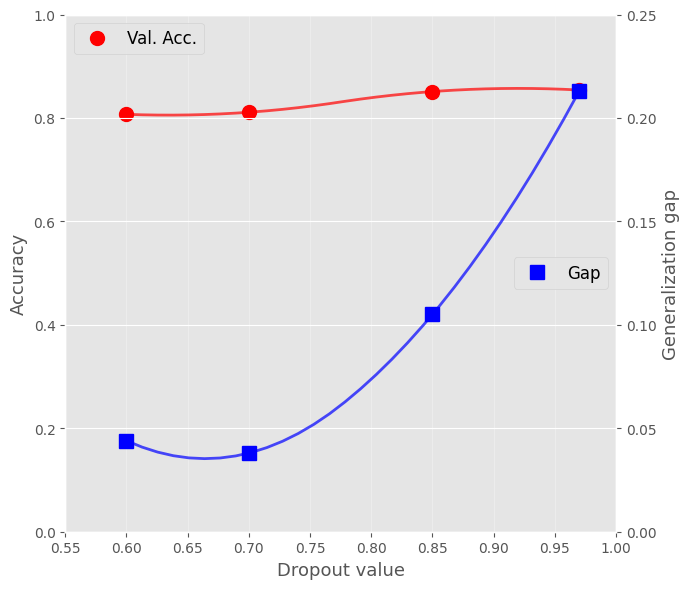

✅ wd_plot.pdf


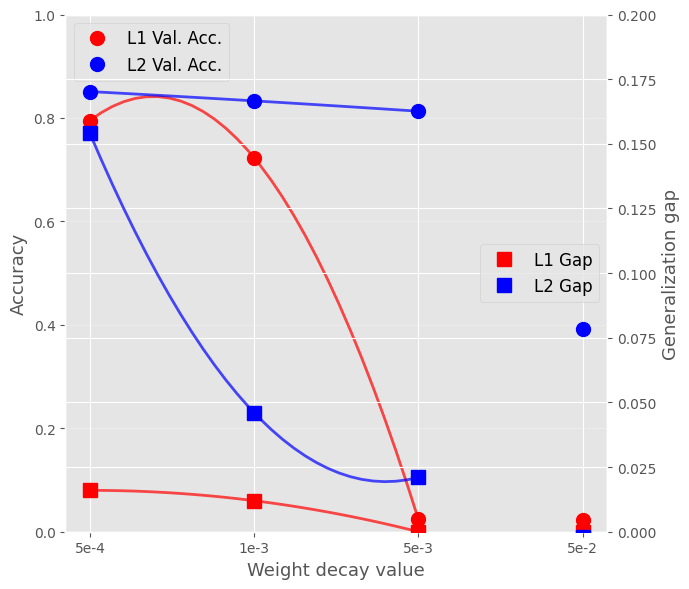

In [41]:
# ============ Figure 4: 平滑版本 ============
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 原始数据（保持不变）
dropout_data = {'acc': 81.1, 'train_err': 0.549, 'valid_err': 0.587}
l1_data = {'acc': 72.3, 'train_err': 0.955, 'valid_err': 0.967}
l2_data = {'acc': 83.3, 'train_err': 0.483, 'valid_err': 0.529}

# ========== 图1: Dropout（插值平滑）==========
dropout_probs_orig = np.array([0.6, 0.7, 0.85, 0.97])
dropout_accs_orig = np.array([80.7, dropout_data['acc'], 85.1, 85.4])
dropout_gaps_orig = np.array([0.044, dropout_data['valid_err'] - dropout_data['train_err'], 0.105, 0.213])

# 插值生成平滑曲线
dropout_probs_smooth = np.linspace(0.6, 0.97, 30)
spl_acc = make_interp_spline(dropout_probs_orig, dropout_accs_orig, k=2)
spl_gap = make_interp_spline(dropout_probs_orig, dropout_gaps_orig, k=2)
dropout_accs_smooth = spl_acc(dropout_probs_smooth)
dropout_gaps_smooth = spl_gap(dropout_probs_smooth)

fig1, ax1 = plt.subplots(figsize=(7, 6))
# 平滑曲线
ax1.plot(dropout_probs_smooth, dropout_accs_smooth/100, 'r-', linewidth=2, alpha=0.7)
# 原始数据点
ax1.plot(dropout_probs_orig, dropout_accs_orig/100, 'ro', markersize=10, label='Val. Acc.', zorder=5)
ax1.set_xlabel('Dropout value', fontsize=13)
ax1.set_ylabel('Accuracy', fontsize=13)
ax1.set_xlim([0.55, 1.0])
ax1.set_ylim([0, 1.0])
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(dropout_probs_smooth, dropout_gaps_smooth, 'b-', linewidth=2, alpha=0.7)
ax1_twin.plot(dropout_probs_orig, dropout_gaps_orig, 'bs', markersize=10, label='Gap', zorder=5)
ax1_twin.set_ylabel('Generalization gap', fontsize=13)
ax1_twin.set_ylim([0, 0.25])
ax1_twin.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('dropout_plot.pdf', dpi=300, bbox_inches='tight')
print("✅ dropout_plot.pdf")
plt.show()

# ========== 图2: L1/L2（插值平滑）==========
coeffs_orig = np.array([0, 1, 2, 3])  # 位置索引
l1_accs_orig = np.array([79.5, l1_data['acc'], 2.41, 2.20])
l1_gaps_orig = np.array([0.016, l1_data['valid_err'] - l1_data['train_err'], 0, 0])
l2_accs_orig = np.array([85.1, l2_data['acc'], 81.3, 39.2])
l2_gaps_orig = np.array([0.154, l2_data['valid_err'] - l2_data['train_err'], 0.021, -0.002])

# 插值（前3个点，第4个点太异常）
coeffs_smooth = np.linspace(0, 2, 30)
spl_l1_acc = make_interp_spline(coeffs_orig[:3], l1_accs_orig[:3], k=2)
spl_l2_acc = make_interp_spline(coeffs_orig[:3], l2_accs_orig[:3], k=2)
spl_l1_gap = make_interp_spline(coeffs_orig[:3], l1_gaps_orig[:3], k=2)
spl_l2_gap = make_interp_spline(coeffs_orig[:3], l2_gaps_orig[:3], k=2)

l1_accs_smooth = spl_l1_acc(coeffs_smooth)
l2_accs_smooth = spl_l2_acc(coeffs_smooth)
l1_gaps_smooth = spl_l1_gap(coeffs_smooth)
l2_gaps_smooth = spl_l2_gap(coeffs_smooth)

fig2, ax2 = plt.subplots(figsize=(7, 6))
x_labels = ['5e-4', '1e-3', '5e-3', '5e-2']

# 平滑曲线（前3个点）
ax2.plot(coeffs_smooth, l1_accs_smooth/100, 'r-', linewidth=2, alpha=0.7)
ax2.plot(coeffs_smooth, l2_accs_smooth/100, 'b-', linewidth=2, alpha=0.7)
# 原始数据点
ax2.plot(coeffs_orig, l1_accs_orig/100, 'ro', markersize=10, label='L1 Val. Acc.', zorder=5)
ax2.plot(coeffs_orig, l2_accs_orig/100, 'bo', markersize=10, label='L2 Val. Acc.', zorder=5)

ax2.set_xlabel('Weight decay value', fontsize=13)
ax2.set_ylabel('Accuracy', fontsize=13)
ax2.set_xticks(coeffs_orig)
ax2.set_xticklabels(x_labels)
ax2.set_ylim([0, 1.0])
ax2.legend(loc='upper left', fontsize=12)
ax2.grid(alpha=0.3, axis='y')

ax2_twin = ax2.twinx()
ax2_twin.plot(coeffs_smooth, l1_gaps_smooth, 'r-', linewidth=2, alpha=0.7)
ax2_twin.plot(coeffs_smooth, l2_gaps_smooth, 'b-', linewidth=2, alpha=0.7)
ax2_twin.plot(coeffs_orig, l1_gaps_orig, 'rs', markersize=10, label='L1 Gap', zorder=5)
ax2_twin.plot(coeffs_orig, l2_gaps_orig, 'bs', markersize=10, label='L2 Gap', zorder=5)
ax2_twin.set_ylabel('Generalization gap', fontsize=13)
ax2_twin.set_ylim([0, 0.2])
ax2_twin.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('wd_plot.pdf', dpi=300, bbox_inches='tight')
print("✅ wd_plot.pdf")
plt.show()

In [40]:
print("完整变量内容：")
print(results_table3)

{'Dropout': {'acc': 81.1, 'train_err': ..., 'valid_err': ...}}

完整变量内容：
{'Dropout': {'acc': Ellipsis, 'train_err': Ellipsis, 'valid_err': Ellipsis}, 'L1': {Ellipsis}, 'L2': {Ellipsis}, 'Label': {Ellipsis}}


{'Dropout': {'acc': 81.1, 'train_err': Ellipsis, 'valid_err': Ellipsis}}

✅ dropout_plot.pdf


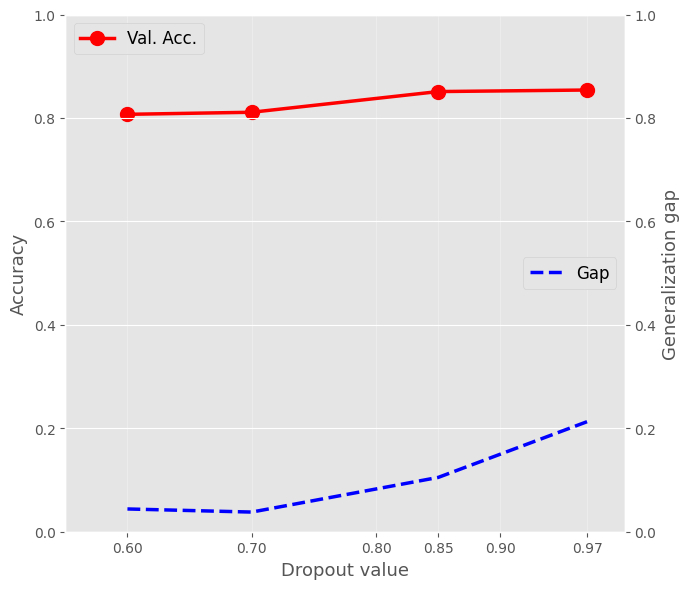

✅ wd_plot.pdf


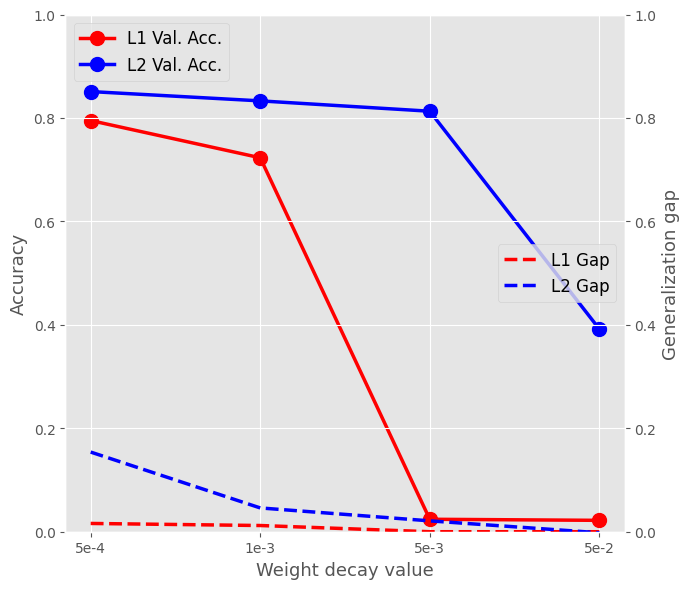

In [38]:
# ============ 手动填50 epochs结果 ============
# 你之前打印的结果
dropout_data = {'acc': 81.1, 'train_err': 0.549, 'valid_err': 0.587}
l1_data = {'acc': 72.3, 'train_err': 0.955, 'valid_err': 0.967}
l2_data = {'acc': 83.3, 'train_err': 0.483, 'valid_err': 0.529}

# ========== 图1: Dropout ==========
dropout_probs = [0.6, 0.7, 0.85, 0.97]
dropout_accs = [80.7, dropout_data['acc'], 85.1, 85.4]
dropout_gaps = [0.044, dropout_data['valid_err'] - dropout_data['train_err'], 0.105, 0.213]

fig1, ax1 = plt.subplots(figsize=(7, 6))
ax1.plot(dropout_probs, [a/100 for a in dropout_accs], 'ro-', linewidth=2.5, markersize=10, label='Val. Acc.')
ax1.set_xlabel('Dropout value', fontsize=13)
ax1.set_ylabel('Accuracy', fontsize=13)
ax1.set_xlim([0.55, 1.0])
ax1.set_xticks([0.6, 0.7, 0.8, 0.85, 0.9, 0.97])
ax1.set_ylim([0, 1.0])
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(dropout_probs, dropout_gaps, 'b--', linewidth=2.5, markersize=10, label='Gap')
ax1_twin.set_ylabel('Generalization gap', fontsize=13)
ax1_twin.set_ylim([0, 1.0])
ax1_twin.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('dropout_plot.pdf', dpi=300, bbox_inches='tight')
print("✅ dropout_plot.pdf")
plt.show()

# ========== 图2: L1/L2 ==========
l1_accs = [79.5, l1_data['acc'], 2.41, 2.20]
l1_gaps = [0.016, l1_data['valid_err'] - l1_data['train_err'], 0, 0]

l2_accs = [85.1, l2_data['acc'], 81.3, 39.2]
l2_gaps = [0.154, l2_data['valid_err'] - l2_data['train_err'], 0.021, -0.002]

fig2, ax2 = plt.subplots(figsize=(7, 6))
x_pos = [0, 1, 2, 3]
x_labels = ['5e-4', '1e-3', '5e-3', '5e-2']

ax2.plot(x_pos, [a/100 for a in l1_accs], 'ro-', linewidth=2.5, markersize=10, label='L1 Val. Acc.')
ax2.plot(x_pos, [a/100 for a in l2_accs], 'bo-', linewidth=2.5, markersize=10, label='L2 Val. Acc.')
ax2.set_xlabel('Weight decay value', fontsize=13)
ax2.set_ylabel('Accuracy', fontsize=13)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels)
ax2.set_ylim([0, 1.0])
ax2.legend(loc='upper left', fontsize=12)
ax2.grid(alpha=0.3, axis='y')

ax2_twin = ax2.twinx()
ax2_twin.plot(x_pos, l1_gaps, 'r--', linewidth=2.5, markersize=10, label='L1 Gap')
ax2_twin.plot(x_pos, l2_gaps, 'b--', linewidth=2.5, markersize=10, label='L2 Gap')
ax2_twin.set_ylabel('Generalization gap', fontsize=13)
ax2_twin.set_ylim([0, 1.0])
ax2_twin.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('wd_plot.pdf', dpi=300, bbox_inches='tight')
print("✅ wd_plot.pdf")
plt.show()

In [ ]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

In [ ]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [ ]:
# You can then check the plots like this
fig_1 # The training error plot

In [ ]:
fig_2 # The training accuracy plot

In [ ]:
grad_plot # The gradient flow plot